# Building a Smart AI Research Agent with LangGraph and AWS Bedrock 🚀

## 📦 1. Package Installation & Imports
First, we install the necessary packages and import key libraries:

In [ ]:
!pip install -qU langgraph langchain langchain-core ddgs pygraphviz boto3 langchain-aws arxiv

🔍 **Explanation**: We're setting up our AI agent with essential libraries. langgraph helps us create agent workflows, langchain provides the LLM framework, and boto3 connects to AWS Bedrock. The tools include DuckDuckGo for web searches and Arxiv for research papers.

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import DuckDuckGoSearchRun
from IPython.display import Markdown, display


## 🛠️ 2. Tool Setup for Research

📚 **Explanation**: We initialize two powerful research tools:

DuckDuckGo Search: For real-time web information gathering 🌐

Arxiv Query Tool: For accessing academic research papers 📄

These tools will allow our agent to find both current news and scholarly information.

In [ ]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

search = DuckDuckGoSearchRun()

# Create the Arxiv API wrapper
arxiv_wrapper = ArxivAPIWrapper()

# Create the Arxiv tool
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

## 🏗️ 3. Agent State Management

⚙️ **Explanation**: This defines the agent's memory structure. The AgentState tracks all conversation messages, with operator.add ensuring new messages are appended to the existing list. This state persistence is crucial for maintaining context throughout multi-step agent workflows


In [53]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

## 🤖 4. Core Agent Architecture

🎯 **Explanation**: This is the heart of our AI agent system:

### Key Components:
- **State Graph**: Creates a workflow with nodes for LLM calls and tool actions

- **Conditional Edges**: Determines whether to continue to tools or end the conversation

- **Tool Management**: Maps tool names to their functions with error handling

- **Message Flow**: Maintains conversation context with system prompts and tool results

### Workflow Logic:

**LLM Node**: Processes user queries and decides if tools are needed 🔍

**Action Node**: Executes the selected tools (search, research, etc.) ⚡

**Feedback Loop**: Tool results return to the LLM for synthesis 🔄

In [54]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_model)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_model(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

## ☁️ 5. AWS Bedrock Nova Model Testing 

🌩️ **Explanation**: We connect to AWS Bedrock, **Amazon's managed LLM service**. The Nova-2-Lite model provides cost-effective AI capabilities. This direct API call demonstrates Bedrock's raw power before integrating it with LangChain.

In [55]:
import boto3
import json

bedrock = boto3.client('bedrock-runtime', region_name='us-east-1')

request_body = {
    'messages': [
        {
            'role': 'user',
            'content': [{'text': 'What is AWS bedrock AgentCore?'}]
        }
    ],
    'inferenceConfig': {
        'maxTokens': 512,
        'temperature': 0.7
    }
}

response = bedrock.invoke_model(
    modelId='us.amazon.nova-2-lite-v1:0',
    body=json.dumps(request_body)
)

response_body = json.loads(response['body'].read())
content_list = response_body["output"]["message"]["content"]
# Extract the first text block
text_block = next((item for item in content_list if "text" in item), None)
if text_block is not None:
   #♣ print(text_block["text"])
    display(Markdown(text_block["text"]))

### **AWS Bedrock AgentCore**

As of the current information available (up to 2024), **AWS Bedrock AgentCore** is **not an officially documented or released service** by Amazon Web Services (AWS). It’s possible that you may have encountered this term in one of the following contexts:

---

## 🔍 Possible Explanations

### 1. **Internal or Pre-Release Terminology**
- AWS frequently develops and tests new features internally before releasing them publicly. **AgentCore** might be an **internal code name**, **internal service**, or **pre-release component** related to AWS Bedrock’s agent-building capabilities.
- AWS Bedrock is a service that allows developers to **build and scale generative AI applications** using foundation models from Amazon and third-party providers.
- In 2023–2024, AWS introduced **Agents in Bedrock**, allowing users to create **AI agents** that can perform tasks using natural language inputs. **AgentCore** could be a backend or core engine powering those agents, but it has not been officially named or documented.

---

### 2. **Misinterpretation or Typo**
- You may have seen a term that sounds similar, such as:
  - **AWS Bedrock Agents**
  - **AWS Agentic Workflows**
  - **Amazon Bedrock Agent Runtime**
- These are real, documented components related to building AI agents on Bedrock.

---

### 3. **Third-Party or Community Projects**
- Some developers or third-party tools may have created custom frameworks or wrappers around AWS Bedrock agents and named them something like **AgentCore**. This would be **community-driven**, not an AWS service.

---

## ✅ What You Might Be Referring To

If you're asking about **AWS Bedrock Agents**, here's a brief overview:

### **AWS Bedrock Agents (Official Service)**

**AWS Bedrock Agents** is a feature of Amazon Bedrock that allows developers to:
- **Build AI agents** that understand user inputs and execute actions (like querying a database, calling APIs, or generating responses).
- **Automate complex workflows** using natural language.
- Integrate with **AWS services**, **custom APIs**, and **knowledge bases**.

#### Key Features:
| Feature | Description |
|--------|-------------|
| **Agent Creation** | Define agents with instructions, action groups, and integration points. |
| **Natural Language Understanding** | Agents parse user intent and determine appropriate actions. |
| **Action Groups** | Predefined or custom APIs that agents can invoke (e.g.,

**Newest Information**: Let's ask for the newest information

In [ ]:
request_body = {
    'messages': [
        {
            'role': 'user',
            'content': [{'text': 'What is the latest MiT news?'}]
        }
    ],
    'inferenceConfig': {
        'maxTokens': 512,
        'temperature': 0.7
    }
}

response = bedrock.invoke_model(
    modelId='us.amazon.nova-2-lite-v1:0',
    body=json.dumps(request_body)
)

response_body = json.loads(response['body'].read())
content_list = response_body["output"]["message"]["content"]
# Extract the first text block
text_block = next((item for item in content_list if "text" in item), None)
if text_block is not None:
   #♣ print(text_block["text"])
    display(Markdown(text_block["text"]))
    

## 🔗 6. LangChain Bedrock Chat Integration

🔌 **Explanation**: We wrap AWS Bedrock with LangChain's ChatBedrock interface, making it compatible with our agent architecture. The parameters control response creativity (temperature=0 for deterministic outputs) and length (max_tokens=1000).

In [56]:
from langchain_aws import ChatBedrock

# Replace the OpenAI model with AWS Nova Lite
model = ChatBedrock(
    model_id="us.amazon.nova-2-lite-v1:0",  
    model_kwargs={
        "temperature": 0,
        "top_p": 1,
        "max_tokens": 1000,
    }
)

## 🎓 7. Research Agent Configuration

🧠 **Explanation**: We create a specialized research agent with:

- **System Prompt**: Guides the agent's behavior as a research assistant

- **Available Tools**: Both web search and academic paper search capabilities

- **Multi-step Reasoning**: Allows sequential information gathering for complex queries

In [ ]:
system_prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""


research_agent = Agent(model, [search, arxiv_tool], system=system_prompt)


## 📊 8. Visualizing the Agent Workflow

📈 **Explanation*: This generates a visual representation of our agent's decision-making flow. You'll see a graph showing how the agent moves between LLM processing and tool execution based on the conversation state.

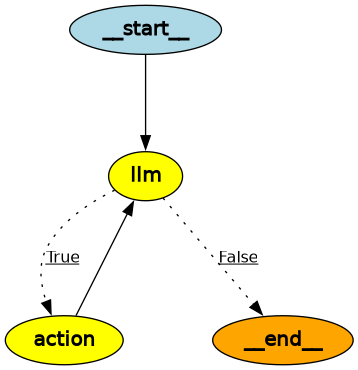

In [ ]:
from IPython.display import Image

Image(research_agent.graph.get_graph().draw_png())

## 🧪 9. Testing the Agent with Research Queries

### Example 1: Current AI News from MIT

In [ ]:
messages = [HumanMessage(content="We are February 2026, What is the latest AI news from MIT?")]
result = research_agent.graph.invoke({"messages": messages})

Calling: {'name': 'duckduckgo_search', 'args': {'query': 'latest AI news from MIT 2026'}, 'id': 'tooluse_Q73Buyjpo351ZqqVuE4NA1', 'type': 'tool_call'}
Back to the model!


🔍 **Agent Behavior**: The agent will:

1- Receive the question about MIT AI news

2- Decide to use DuckDuckGo search

3- Process search results

4- Synthesize findings into a coherent response

In [83]:
result

{'messages': [HumanMessage(content='We are February 2026, search the latest AI architectural diagrams released by AWS, add the links', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'latest AI architectural diagrams released by AWS 2026'}, 'id': 'tooluse_uhlzEh9Z94CxbmdYVYS9fM'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '955f77a0-7efb-4943-a234-63ea9b152889', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 04 Feb 2026 00:38:41 GMT', 'content-type': 'application/json', 'content-length': '354', 'connection': 'keep-alive', 'x-amzn-requestid': '955f77a0-7efb-4943-a234-63ea9b152889'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [377]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.amazon.nova-2-lite-v1:0'}, id='lc_run--019c2616-48f4-7e43-a8e8-1ee30633dcf2-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest A

In [61]:
display(Markdown(result['messages'][-1].content))

Here are some of the latest AI news highlights from MIT as of early 2026:

### **Key AI Trends and Developments from MIT in Early 2026**

1. **MIT Sloan Management Review (SMR) Insights (January 6, 2026)**  
   - **AI Trends for 2026**: Columnists Thomas H. Davenport and Randy Bean identified five major trends:
     - **Deflation of the AI "bubble"**: Economic impacts from cooling down overhyped AI expectations.
     - **Growth of AI "factory" infrastructure**: Organizations are building scalable systems to support AI adoption.
     - **Shift to generative AI as an organizational resource**: Focus is moving from individual tools to enterprise-wide generative AI applications.
     - **Progress toward agentic AI**: Development of AI systems that can act autonomously to deliver value, despite challenges.

2. **MIT Technology Review's 2026 Breakthrough Technologies List (January 27, 2026)**  
   - AI was featured among the **10 Breakthrough Technologies** expected to shape the future. The list highlights transformative innovations across AI, biotech, space, and energy.

3. **Expert Predictions for 2026 (January 1, 2026)**  
   - Reporter Anabelle Nicoud interviewed experts in AI, security, and quantum computing to explore where technology—especially AI—will take us in 2026.

### **What to Watch in AI at MIT in 2026**
- **Agentic AI**: Continued progress toward systems that can plan, execute, and adapt independently.
- **Generative AI at Scale**: Enterprise adoption and integration of generative models into business workflows.
- **Ethical and Economic Impacts**: Addressing the fallout from the "AI bubble" and ensuring responsible deployment.

These updates reflect MIT’s ongoing leadership in tracking and analyzing AI’s evolving role in technology and society. For deeper insights, you can explore the original articles from [MIT Sloan Review](https://sloanreview.mit.edu) and [MIT Technology Review](https://www.technologyreview.com). 

Let me know if you'd like summaries of any specific articles or trends!

### Example 2: Latest AI Research Papers

📄 **Agent Behavior**: The agent uses the **Arxiv tool** to find recent academic papers, demonstrating its ability to access scholarly resources.

In [ ]:
messages = [HumanMessage(content="What is the latest AI research paper released?")]
result = research_agent.graph.invoke({"messages": messages})

Calling: {'name': 'arxiv', 'args': {'query': 'AI research paper'}, 'id': 'tooluse_IpEhRR71LzkaYVQSSy7zik', 'type': 'tool_call'}
Back to the model!


In [63]:
display(Markdown(result['messages'][-1].content))

The latest AI research paper released in February 2026 is titled **"Competing Visions of Ethical AI: A Case Study of OpenAI"**. It was published on **January 23, 2026**, and authored by **Melissa Wilfley, Mengting Ai, and Madelyn Rose Sanfilippo**.

### Summary of the Paper:
The paper investigates how OpenAI frames ethical AI discourse in its public communications. It analyzes how terms like *"ethics," "safety," "alignment,"* and related concepts are used across different audiences (general public vs. academic). The study uses a combination of **qualitative content analysis** and **computational NLP methods** to track changes in rhetoric over time.

#### Key Findings:
- **Safety and risk** dominate OpenAI’s public discourse, with little use of academic ethics frameworks or vocabularies typically employed by advocacy groups or researchers.
- The paper highlights potential **ethics-washing** practices within the industry, where ethical language may be used more for PR than substantive governance.

The authors have made their code and data publicly available on GitHub for reproducibility: [https://github.com/famous-blue-raincoat/AI_Ethics_Discourse](https://github.com/famous-blue-raincoat/AI_Ethics_Discourse).

If you'd like further details or insights from this paper, let me know!

### Example 3: More complex Request

The user give more instruction to the AI agent. We can configure an Advanced Researcher Agent with this prompt. The user need only to specify the field.

**Hint**: Check the given Arxiv reference
The Agent gives Sola-Visibility-ISPM Benchmark - Source: **arXiv:2601.01234** while its real reference is **arXiv:2601.07880**



In [ ]:
messages = [HumanMessage(content="""What is the newest papers on ai agents security? 

Output structure: Use this exact format for every response.



## EXECUTIVE SUMMARY

[Core insight. Current field state.]

## KEY DEVELOPMENTS (Last 3-6 months)

[Development] - Source(s): [Type, Identifier]
• Impact: [High/Medium/Low]
• Confidence: [High/Medium/Low based on evidence]

## EMERGING TRENDS

[Trend 1] | Strength: [Strong/Moderate/Weak evidence]
[Trend 2] | Strength: [Strong/Moderate/Weak evidence]

## RESEARCH FRONTIERS (arXiv Focus)

[Frontier 1: Key finding & arXiv ID]
[Frontier 2: Key finding & arXiv ID]

## KNOWLEDGE GAPS

[Unanswered question] - [Significance]
[Unanswered question] - [Significance]

## PRACTICAL IMPLICATIONS

Short-term (0-1yr): [Applications]
Long-term (3-5+yrs): [Possibilities]

## RISK ASSESSMENT

Technical: [e.g., reproducibility, scale]
Societal: [e.g., ethical, misuse]

## MONITOR

Watch: [Authors, institutions, events]

Operational rules:

Always cite specific sources (e.g., arXiv:1234.56789, Nature News).

Distinguish preprint claims from peer-reviewed findings.

Flag speculation and low-confidence insights.

Calibrate confidence based on evidence quality and source reproducibility.

""")]
result = research_agent.graph.invoke({"messages": messages})
display(Markdown(result['messages'][-1].content))